In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns



In [2]:
df=pd.read_csv("D:\week 8\data\cleaned_data.csv")

In [3]:
nyc=df[df["city"]=="New York City"]

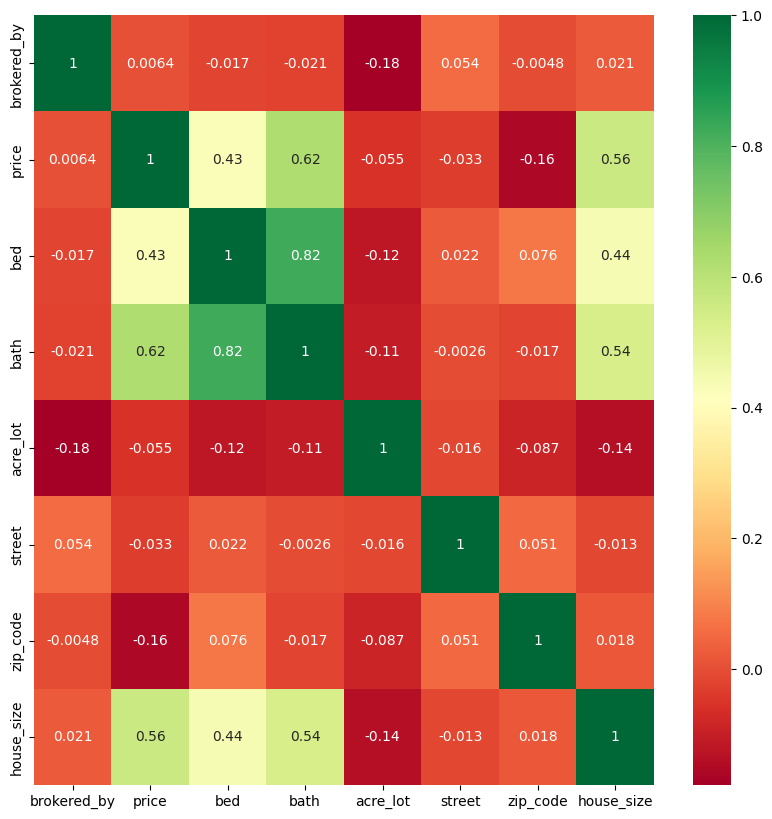

In [4]:
plt.figure(figsize=(10,10))
sns.heatmap(nyc.select_dtypes(include='number').corr(), annot=True, cmap="RdYlGn")
plt.show()

THE CMAP EXPLAINS THE CO-RELATION BETWEEN PRICE,BED,BATH AND BROKERED BY COLOUMN THIS CAN BE FURTHER USED FOR ANALYSIS AND PREDICTIONS

In [6]:
import scipy.stats as stats


groups = [group["price"].values for name, group in nyc.groupby("bed")]


f_stat, p_val = stats.f_oneway(*groups)

print("ANOVA F-statistic:", f_stat)
print("p-value:", p_val)

if p_val < 0.05:
    print("Result: Significant difference in average prices across bedroom counts.")
else:
    print("Result: No significant difference in average prices across bedroom counts.")

ANOVA F-statistic: 194.04006104027624
p-value: 0.0
Result: Significant difference in average prices across bedroom counts.


In [7]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=nyc["price"], groups=nyc["bed"], alpha=0.05)
print(tukey)

c:\ProgramData\anaconda3\envs\myenv\Lib\site-packages\scipy\integrate\_quadpack_py.py:1272: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
group1 group2    meandiff    p-adj      lower          upper      reject
------------------------------------------------------------------------
   1.0    2.0    839426.6647    0.0    541575.8428   1137277.4866   True
   1.0    3.0   2503252.5374    0.0   2136989.7354   2869515.3395   True
   1.0  3.275      5343.0943    1.0   -406770.5443     417456.733  False
   1.0    4.0    5097371.328    0.0    4576349.424    5618393.232   True
   1.0    5.0   6050476.3815    0.0   5352237.4492   6748715.3138   True
   1.0    6.0   7217689.0721    0.0   6398770.3728   8036607.7714   True
   1.0    7.0   5105591.4164    0.0   3795302.2426   6415880.5903   True
   1.0    8.0   4224423.5419    0.0   2748890.1239   5699956.9599   True
   1.0    9.0   3679796.8086    0.0   1395727.5809   5963866.0362   True
   1.0   10.0    6362688.936    0.0   4112179.3616   8613198.5105   True
   1.0   11.0   4993442.6419    0.0   1720151.5286 

- Significant Differences (reject = True)
- Example: 1 vs 2 bedrooms → mean difference ≈ ₹839,426, p < 0.001 → significant.
- 1 vs 3 bedrooms → mean difference ≈ ₹2.5M, p < 0.001 → significant.
- 1 vs 4 bedrooms → mean difference ≈ ₹5.1M, p < 0.001 → significant.
- 1 vs 16 bedrooms → mean difference ≈ ₹24.1M, p < 0.001 → significant.
- 46 vs 123 bedrooms → mean difference ≈ ₹100M, p < 0.001 → significant.
- 👉 Interpretation: As bedroom count increases, average house price rises significantly, especially between small homes (1–3 bedrooms) and large estates (10+ bedrooms).
- Non-Significant Differences (reject = False)
- Example: 1 vs 3.275 bedrooms → mean difference ≈ ₹5,343, p = 1.0 → not significant.
- 1 vs 13 bedrooms → mean difference ≈ ₹5.4M, but p = 0.600 → not significant.
- 1 vs 14 bedrooms → mean difference ≈ ₹3.5M, but p = 0.995 → not significant.
- 👉 Interpretation: Some bedroom categories don’t show statistically significant differences, possibly due to small sample sizes or high variance.





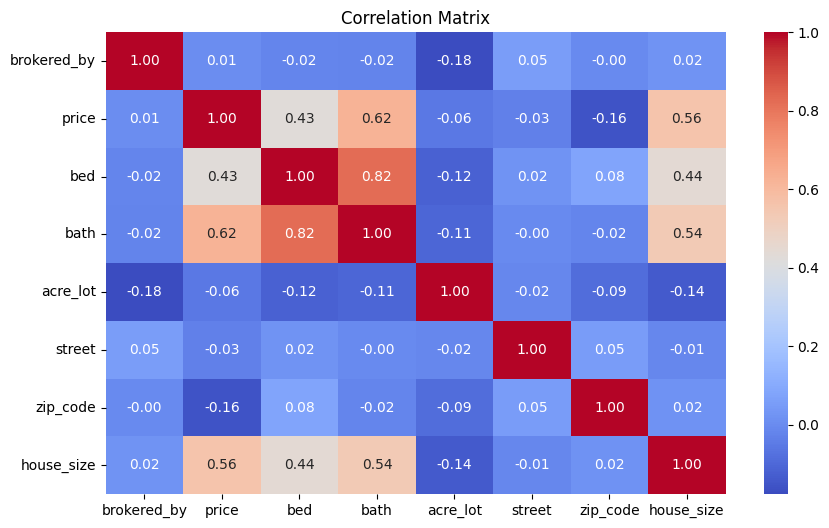

In [8]:


# Compute correlation matrix
corr = nyc.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [16]:
import numpy as np
nyc["log_price"] = np.log(nyc["price"])
X = nyc[["bed", "bath", "acre_lot","street","house_size","brokered_by","zip_code"]]
y = nyc["log_price"]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.508
Model:                            OLS   Adj. R-squared:                  0.508
Method:                 Least Squares   F-statistic:                     1866.
Date:                Sat, 24 Jan 2026   Prob (F-statistic):               0.00
Time:                        19:36:11   Log-Likelihood:                -12935.
No. Observations:               12634   AIC:                         2.589e+04
Df Residuals:                   12626   BIC:                         2.595e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          16.4988      0.115    143.126      

C:\Users\Kaif\AppData\Local\Temp\ipykernel_21528\1059494385.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nyc["log_price"] = np.log(nyc["price"])


 Interpretation
- Bathrooms and house size are the strongest positive predictors of price.
- Bedrooms show a negative effect once bathrooms and house size are controlled — again pointing to multicollinearity (bedrooms and bathrooms are correlated, bathrooms capture most of the value).
- Lot size (acre_lot) has a negligible effect, slightly negative.
- Street and zip_code are acting as categorical proxies — they’re significant but may not be interpretable directly (better encoded as categorical dummies).
- Brokered_by is not significant → doesn’t add explanatory power.


